# 04. 초기값 설정 문제와 방지 기법

## 1. 가중치 초기화가 중요한 이유

신경망 학습의 출발점인 초기 가중치를 어떻게 설정하느냐에 따라 각 층을 통과한 **활성값(Activation values)들의 분포**가 결정됩니다.

- **핵심 목표:** 깊은 신경망의 모든 층에서 **활성값의 분산을 적절하게 유지**하는 것
- **잘못된 초기화의 부작용:** 활성값이 양극단으로 쏠리거나 한 점으로 뭉치게 되어, 역전파 과정에서 기울기가 $0$이 되어버리는 학습 불능 상태를 유발합니다.

---

## 2. Naïve(단순 랜덤) 초기화의 2가지 비극

단순히 표준정규분포에 특정 상수를 곱해 가중치를 채우는 방식은 층이 깊어질 때 치명적인 문제를 일으킵니다.

- **가중치 분산이 너무 클 때 ($\sigma = 1.0$) => 기울기 소실**
- **현상:** 은닉층의 출력값이 $0$과 $1$이라는 양극단으로 쏠립니다.
- **결과:** Sigmoid 함수 특성상 양끝단의 기울기는 $0$에 가깝기 때문에 역전파 시 가중치 업데이트가 멈추는 기울기 소실(Vanishing Gradient)이 발생합니다.


- **가중치 분산이 너무 작을 때 ($\sigma = 0.01$) => 뉴런 다양성 상실 및 표현력 제한**
- **현상:** 모든 은닉층의 출력값이 중앙인 **$0.5$ 부근에 뭉칩니다.**
- **결과:** 굳이 뉴런을 여러 개 둔 이유가 사라집니다(대칭성 문제). 층을 아무리 깊게 쌓아도 모든 레이어가 똑같은 신호만 처리하므로 복잡한 경계를 배우는 **신경망의 표현력(Capacity)이 완전히 상실**됩니다.



---

## 3. 입출력 노드를 고려한 적절한 초기화 기법

현대 딥러닝에서는 앞 단 레이어의 입력 노드 수($n_{\mathrm{in}}$)에 맞춰 가중치의 분산을 수학적으로 계산하여 스케일링합니다.

###  Xavier (Glorot) 초기화 => Sigmoid / Tanh 계열과 찰떡궁합

선형 함수에 가까운 활성화 함수를 쓸 때 활성값의 분산을 보존하도록 설계되었습니다.

$$W \sim N\left(0, \ \frac{1}{n_{\mathrm{in}}}\right) \quad \left(\text{표준정규분포} \times \frac{1}{\sqrt{n_{\mathrm{in}}}}\right)$$

### ② He 초기화 => ReLU 계열과 찰떡궁합

ReLU 함수는 입력이 음수일 때 출력을 0으로 반사시켜 활성값이 절반 죽는 성질이 있습니다. 이를 보완하기 위해 Xavier보다 분산을 2배 더 넓게 가져갑니다.

$$W \sim N\left(0, \ \frac{2}{n_{\mathrm{in}}}\right) \quad \left(\text{표준정규분포} \times \sqrt{\frac{2}{n_{\mathrm{in}}}}\right)$$

---

## 실무 매칭 가이드

> - **Xavier 초기화와 ReLU를 조합하지 마세요.**
> ReLU를 쓰는 층에 Xavier 초기화를 적용하면, 층이 깊어질수록 활성값의 분산이 점점 죽어 결국 **출력값이 $0$으로 수렴**해 버리는 현상이 발생합니다.

- **현대 딥러닝의 표준:** 대부분의 현대 딥러닝 모델은 은닉층 활성화 함수로 `ReLU` 또는 그 변형들을 사용하므로, 가중치 초기화 역시 He 초기화(He Normal / He Uniform)를 기본 디폴트로 사용합니다.

## 0. 환경 설정


In [8]:
# Colab에는 TensorFlow가 기본 설치되어 있습니다.
import sys
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 운영체제가 macOS('darwin')가 아닐 경우 (예: 구글 코랩 등 리눅스 환경),
# 한글 출력을 위한 나눔 폰트를 설치하고 폰트 캐시를 초기화합니다.
if sys.platform != 'darwin':
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    !fc-cache -fv 2>/dev/null
    !rm -rf ~/.cache/matplotlib 2>/dev/null

import seaborn as sns

# 나눔 폰트 파일 시스템 경로를 순회하며 matplotlib 폰트 관리자에 등록합니다.
for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

# matplotlib 및 seaborn의 기본 설정을 변경합니다 (한글 깨짐 방지, 마이너스 부호 깨짐 방지, 고해상도 설정)
plt.rcParams.update({'font.family': 'NanumBarunGothic', 'axes.unicode_minus': False, 'figure.dpi': 110})
sns.set_theme(style='whitegrid', font='NanumBarunGothic', rc={'axes.unicode_minus': False})

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))



/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache director

## 1) 초기화 후 층별 출력 분산 비교

### 1. 실험의 목적

- 가중치 초기화(Weight Initialization)와 활성화 함수(Activation Function)의 조합이 심층 신경망을 통과하는 '데이터의 분포(층별 표준편차)'에 미치는 영향을 검증합니다.
- 초기화가 잘못되면 층이 깊어질 때 기울기 소실(Gradient Vanishing)이나 **표현력 상실**이 발생함을 시각적으로 보여줍니다.

### 2. 5가지 설정별 실험 결과

- **성공적인 조합 (안정적인 학습 가능)**
  + **He + ReLU**: ReLU의 특성(음수 제거)을 보완하기 위해 가중치를 더 크게 초기화하는 기법으로, 깊은 층에서도 표준편차가 **0.8 부근으로 가장 안정적으로 유지**됩니다.
  + **Xavier + Tanh**: 0 중심 대칭인 Tanh에 맞춘 표준 초기화로, 층이 깊어져도 표준편차가 **0.3~0.6 사이에서 균형**을 이룹니다.

- **실패하는 조합 (학습 불가 또는 성능 저하)**
  + **큰 분산 + Sigmoid**: 출력이 0과 1로 극단화되어 표준편차는 커 보이지만, 미분값이 0이 되어 **기울기 소실**이 발생합니다.
  + **작은 분산 + Sigmoid**: 출력이 모두 0.5 부근으로 뭉쳐 표준편차가 0으로 수렴하며, 신경망의 **표현력을 상실**합니다.
  + **Xavier + ReLU (부적합)**: ReLU와 Xavier를 잘못 조합하여, 층을 거칠수록 데이터의 분산이 반토막 나며 **표준편차가 계속 우하향**합니다.


큰 분산+sigmoid         std=[0.448, 0.425, 0.428, 0.443, 0.449, 0.448]
작은 분산+sigmoid        std=[0.02, 0.01, 0.01, 0.01, 0.01, 0.01]
Xavier+tanh          std=[0.627, 0.484, 0.399, 0.351, 0.312, 0.288]
He+relu              std=[0.829, 0.833, 0.888, 1.055, 1.053, 1.019]
Xavier+relu(부적합)     std=[0.595, 0.411, 0.303, 0.201, 0.139, 0.095]


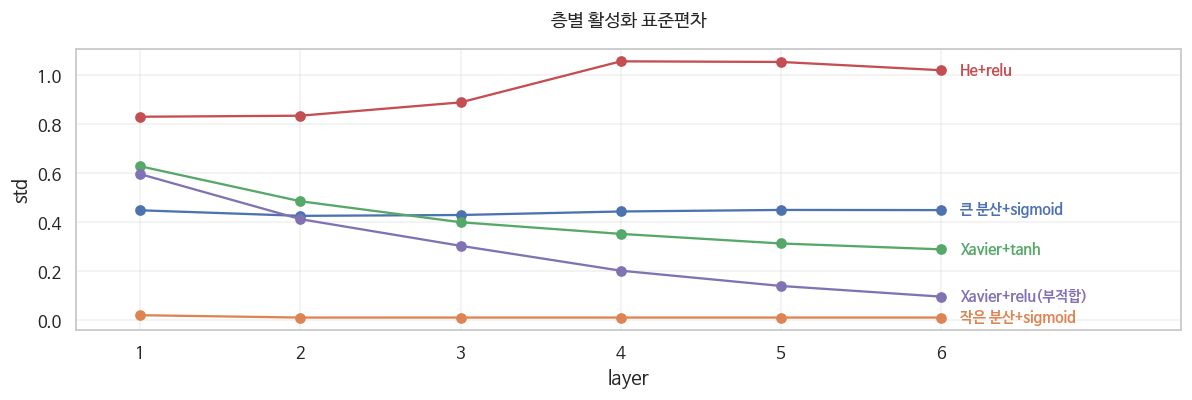

In [5]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. 실험용 심층 신경망(MLP) 생성 함수
def stacked(activation, initializer, depth=6, units=64):
    m = keras.Sequential()
    # 입력층 정의 (입력 크기: 64)
    m.add(layers.Dense(units, activation=activation, kernel_initializer=initializer, input_shape=(64,)))
    # 설정된 깊이(depth)만큼 은닉층을 반복해서 쌓음
    for _ in range(depth - 1):
        m.add(layers.Dense(units, activation=activation, kernel_initializer=initializer))
    return m

# 2. 더미 입력 데이터 생성 (1000개의 샘플, 64개의 특징치 / 평균 0, 표준편차 1인 정규분포)
x = tf.random.normal((1000, 64))

# 3. 테스트할 5가지 가중치 초기화 및 활성화 함수 조합 설정
configs = [
    ("큰 분산+sigmoid", "sigmoid", keras.initializers.RandomNormal(stddev=1.0)),
    ("작은 분산+sigmoid", "sigmoid", keras.initializers.RandomNormal(stddev=0.01)),
    ("Xavier+tanh", "tanh", "glorot_normal"),
    ("He+relu", "relu", "he_normal"),
    ("Xavier+relu(부적합)", "relu", "glorot_normal"),
]

# 4. 시각화를 위한 플롯 설정 (우측 텍스트 라벨 공간 확보를 위해 가로 크기를 살짝 늘림)
fig, ax = plt.subplots(figsize=(11, 3.8))

# 5. 각 설정별로 모델을 만들고 순전파(Forward Propagation)를 수행하며 표준편차 측정
for title, act, init in configs:
    model = stacked(act, init)
    h = x
    stds = []

    # 모델의 각 층을 순서대로 통과시키며 출력(활성화 값)의 표준편차를 기록
    for layer in model.layers:
        h = layer(h) # 현재 층의 출력값이 다음 층의 입력값(h)이 됨
        stds.append(float(tf.math.reduce_std(h))) # 활성화 값의 표준편차 계산 및 저장

    # 층별 표준편차 변화를 선 그래프로 시각화
    x_ticks = list(range(1, len(stds) + 1))
    line, = ax.plot(x_ticks, stds, marker="o") # 색상 정보를 가져오기 위해 line 객체 언패킹

    # [변경] 범례 대신 각 선의 마지막 데이터 포인트 우측에 직접 텍스트 라벨링 추가
    # x_ticks[-1] + 0.12 만큼 우측 여백을 두고 글자를 배치합니다.
    ax.text(x_ticks[-1] + 0.12, stds[-1], title,
            color=line.get_color(),   # 선 색상과 일치
            fontsize=9.5,
            va='center',              # Y축 기준 중앙 정렬로 선 끝에 맞춤
            fontweight='bold')        # 시인성을 위해 굵게 처리

    # 콘솔창에 수치 데이터 출력
    print(f"{title:20s} std={ [round(s,3) for s in stds] }")

# 6. 그래프 스타일링 및 출력
ax.set_title("층별 활성화 표준편차", pad=15)
ax.set_xlabel("layer")
ax.set_ylabel("std")

# [변경] 우측 글자가 잘리지 않도록 x축 한계값을 7.5까지 확장하되, 눈금(Tick)은 6까지만 표시
ax.set_xlim(0.6, 7.5)
ax.set_xticks(range(1, 7))

# 기존 ax.legend() 코드는 제거하여 시각적 노이즈를 최소화했습니다.
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 2) 초기화에 따른 학습 곡선 (쉬운 비교)


### 1. 실험의 목적

- 앞선 실험(층별 활성화 분산 측정)에서 확인한 초기화 상태가 **실제 모델의 학습 속도 및 성능(Loss 감소)에 어떤 직접적인 영향을 미치는지** 이진 분류 문제를 통해 검증합니다.

### 2. 4가지 조합별 학습 결과 (Loss 변화)

- **성공 그룹 (원활한 학습)**
  + **`He + relu`**: 현대 딥러닝의 표준 조합답게 **가장 빠르고 안정적으로 Loss가 감소**합니다. 비선형 경계를 효과적으로 찾아내며 최적의 성능을 냅니다.
  + **`Xavier + tanh`**: 고유의 균형 잡힌 분산 덕분에 초기부터 **Loss가 매끄럽게 하강**하며 정상적으로 학습이 완료됩니다.


- **실패 그룹 (학습 정체 / 기울기 소실)**
  + **`naive std=1 + sigmoid`**: 층을 거칠 때마다 활성화 값이 극단(0 또는 1)으로 치우쳐 기울기 소실(Gradient Vanishing)이 발생합니다. 그 결과 30 에포크가 지나도 Loss가 거의 줄어들지 않고 정체됩니다.
  + **`naive std=0.01 + sigmoid`**: 가중치가 지나치게 작아 모든 활성화 출력이 0.5 부근으로 뭉칩니다. 모델이 아무것도 배우지 못하는 상태가 되어, 무작위 찍기 수준의 높은 Loss(약 0.69 부근)에서 **학습이 완전히 멈춰버립니다.**



### 3. 핵심 시사점

- 가중치 초기화(Weight Initialization)는 단순히 데이터의 분포를 예쁘게 유지하는 것을 넘어, **모델의 실제 학습 가능 여부와 수렴 속도를 결정짓는 치명적인 요소**입니다.
- ReLU에는 He, Tanh에는 Xavier를 쓰는 것이 선택이 아닌 필수임을 보여주는 실험입니다.


naive std=1 + sigmoid        end loss=0.3289
naive std=0.01 + sigmoid     end loss=0.5871
Xavier + tanh                end loss=0.0704
He + relu                    end loss=0.0508


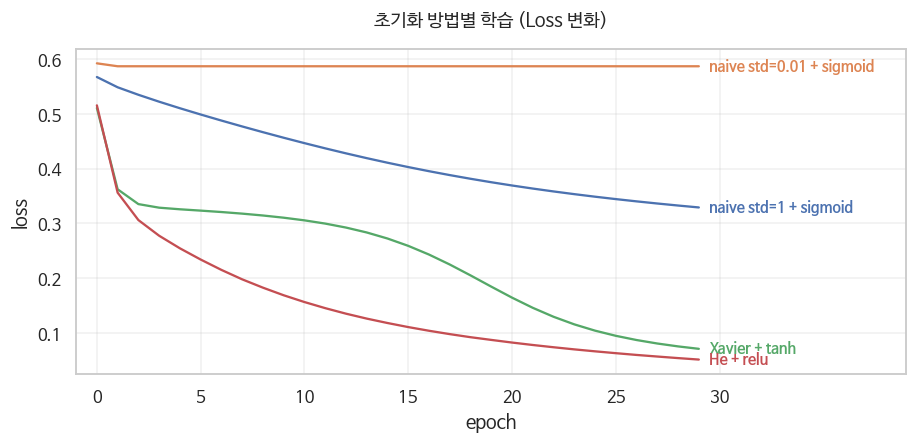

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. 간단한 분류 데이터 생성 (2000개 샘플, 10개 특성)
n = 2000
X = np.random.randn(n, 10).astype("float32")
# 비선형 경계를 가진 이진 분류 타깃 생성
y = ((X[:, 0]**2 - X[:, 1] + 0.3 * X[:, 2]) > 0).astype("float32")

# 2. 초기화 기법별 모델 생성 및 학습 함수 정의
def train_with(init_name, activation, initializer):
    m = keras.Sequential([
        layers.Dense(64, activation=activation, kernel_initializer=initializer, input_shape=(10,)),
        layers.Dense(64, activation=activation, kernel_initializer=initializer),
        layers.Dense(64, activation=activation, kernel_initializer=initializer),
        layers.Dense(1, activation="sigmoid"), # 이진 분류용 출력층
    ])
    # 경사하강법(SGD) 학습률 0.05 설정
    m.compile(optimizer=keras.optimizers.SGD(0.05), loss="binary_crossentropy")
    # 30 에포크 동안 학습 진행 (verbose=0으로 로그 출력 생략)
    h = m.fit(X, y, epochs=30, batch_size=64, verbose=0)
    return h.history["loss"]

# 3. 테스트할 4가지 조합 설정
experiments = [
    ("naive std=1 + sigmoid", "sigmoid", keras.initializers.RandomNormal(stddev=1.0)),
    ("naive std=0.01 + sigmoid", "sigmoid", keras.initializers.RandomNormal(stddev=0.01)),
    ("Xavier + tanh", "tanh", "glorot_normal"),
    ("He + relu", "relu", "he_normal"),
]

# 4. 시각화 플롯 설정 (우측 라벨 공간 확보를 위해 가로폭을 확장)
fig, ax = plt.subplots(figsize=(8.5, 4.2))

# 5. 각 조합별 실행 및 그래프 작성
for name, act, init in experiments:
    loss = train_with(name, act, init)

    # 선 그래프 시각화 및 고유 색상 추출을 위해 line 객체 언패킹
    line, = ax.plot(loss)

    # [변경 핵심] 범례 상자 대신 마지막 에포크 우측에 직접 라벨링
    # x좌표: 마지막 에포크 인덱스 (29) + 약간의 오프셋 (예: 0.5)
    x_label = len(loss) - 1 + 0.5
    # y좌표: 마지막 Loss 값
    y_label = loss[-1]

    ax.text(x_label, y_label, name,
            color=line.get_color(),   # 그래프 선과 동일한 색상 적용
            fontsize=9.5,
            va='center',              # 수직 기준선 중앙 정렬
            fontweight='bold')        # 굵은 글씨로 가독성 확보

    print(f"{name:28s} end loss={loss[-1]:.4f}")

# 6. 그래프 스타일링 및 출력
ax.set_title("초기화 방법별 학습 (Loss 변화)", pad=15)
ax.set_xlabel("epoch")
ax.set_ylabel("loss")

# [변경] 우측 글자가 잘리지 않도록 x축 한계를 39까지 확장
# (데이터는 29까지만 있지만 여백 확보)
ax.set_xlim(-1, 39)
# 눈금(Tick)은 실제 학습 범위(30)까지만 5 단위로 깔끔하게 출력
ax.set_xticks(range(0, 31, 5))

# ax.legend() 코드는 시각적 노이즈 제거를 위해 삭제되었습니다.
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 선택 가이드
| 활성화 함수 | 추천 초기화 | Keras 이름 |
|-------------|-------------|------------|
| Sigmoid / Tanh | Xavier | `glorot_normal` / `glorot_uniform` |
| ReLU 계열 | He | `he_normal` / `he_uniform` |
